# Non-Uniform Azimuthal Poisson Solver: $N$ vs. $M$ Analysis & Disk Error Comparisons

This notebook evaluates the **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT** solvers on a disk $\mathcal{B}(0, R)$ for a Poisson problem with a localized high-frequency azimuthal wave packet:
$$
u(r, \theta) = r^2 \left(R^2 - r^2\right) \frac{\cos(k \theta)}{1 - \gamma \cos(\theta - \theta_0)}
$$
with $k=4$, sharpness $\gamma = 0.65$, and homogeneous Dirichlet boundary conditions $u(R, \theta) = 0$.

## 1. Configurable Parameters & Setup
All problem, mesh, and solver parameters are configured in the cell below:

In [8]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in path
repo_root = r"c:\Users\charl\NUFFTRR_Poisson"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from Tests.paper.helpers import (
    get_azimuthal_benchmark_problem,
    generate_adapted_clustered_azimuthal,
    run_benchmark_case,
    run_all_algorithms_NxM_study,
    render_algorithm_tables,
    plot_solution_and_grids,
    plot_accuracy_and_runtimes_from_df,
    plot_3x3_disk_error_comparison,
    plot_adapted_vs_highres_uniform
)

# =========================================================================
# Configurable Problem & Grid Parameters
# =========================================================================
R = 1.0                     # Disk radius
THETA_0 = np.pi             # Center angle of localized feature (radians)
K_MODE = 4                  # Azimuthal wave frequency
GAMMA = 0.65                # Angular sharpness parameter in [0, 1)

# Solver & Radial Grid Settings
QUAD_RULE = 2               # 1: Trapezoidal, 2: Simpson's rule
BC_CHOICE = 1               # 1: Dirichlet, 2: Neumann
CLUSTER_STRENGTH = 0.40     # Angular clustering factor in [0, 1)

# N vs M Sweep Grids
N_VALUES = [16, 24, 32, 48, 64, 128]
M_VALUES = [16, 32, 64, 128, 256]

# High-Resolution Uniform Comparison Settings
N_LOW_ADAPT = 32
N_HIGH_UNIFORM = 256
M_FIXED_PLOTS = 64

## 2. Problem Setup and Disk Grid Visualization
3D analytical solution $u(x,y)$ on the disk, clean polar grid comparison, and 1D angular slice profile.

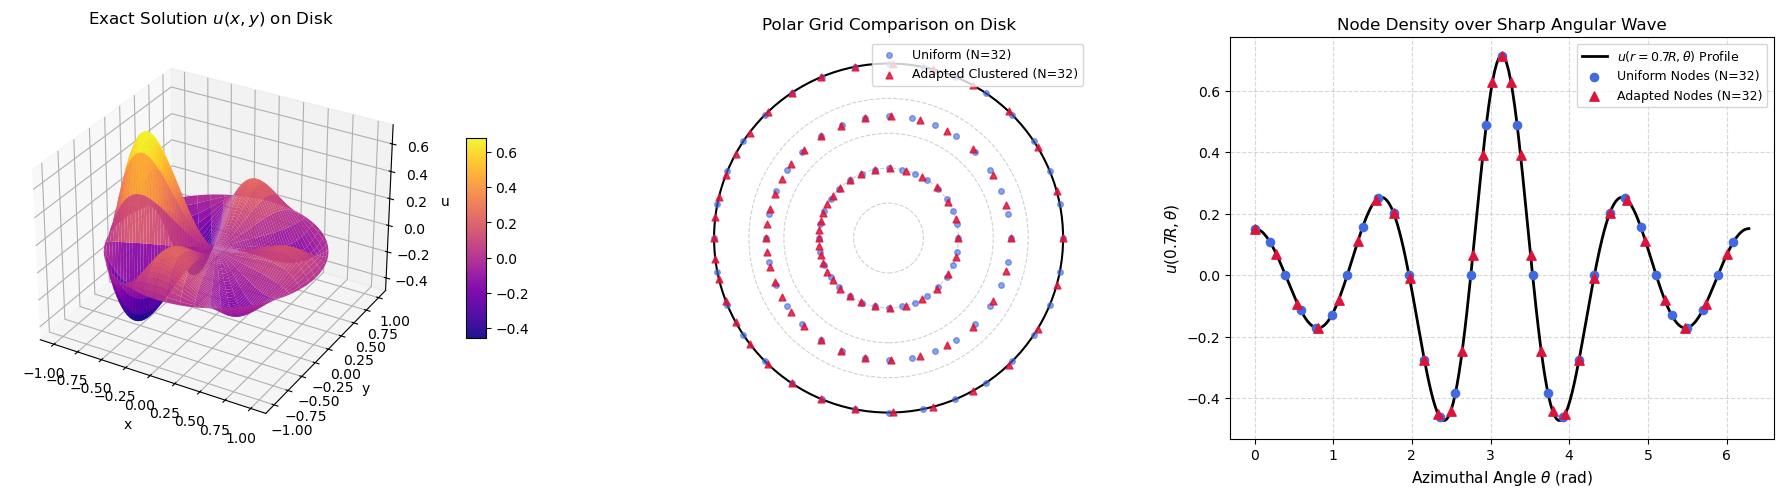

In [9]:
# Construct benchmark problem
problem = get_azimuthal_benchmark_problem(
    R=R, theta_0=THETA_0, k_mode=K_MODE, gamma=GAMMA
)

# Visualize 3D solution surface and 2D polar lattice
plot_solution_and_grids(
    problem=problem,
    N_adapt=32,
    N_unif=32,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0
)

## 3. $N$ vs. $M$ Grid Study for All Three Algorithms
We compute the full $(N \times M)$ matrix of relative $L_2$ errors and execution times for **Adapted NUFFT**, **Adapted NUDFT**, and **Uniform FFT**.

In [10]:
df_results = run_all_algorithms_NxM_study(
    problem=problem,
    N_values=N_VALUES,
    M_values=M_VALUES,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    bc_choice=BC_CHOICE,
    quad_rule=QUAD_RULE
)

Computing N vs M Grid Matrix: 100%|██████████| 90/90 [00:04<00:00, 18.83it/s]


## 4. $L_2$ Error & Runtime Tables ($N$ vs. $M$)
Relative $L_2$ error tables for each algorithm across $N$ (rows) and $M$ (columns).

In [11]:
# Relative L2 Error Tables for each algorithm
error_tables = render_algorithm_tables(df_results, value_col="L2_rel", format_sci=True)

# Runtime (seconds) Tables for each algorithm
runtime_tables = render_algorithm_tables(df_results, value_col="runtime", format_sci=False)


Adapted NUFFT — Relative L₂ Error (N vs M)


M,16,32,64,128,256
N,,,,,
16,3.39e-01,3.40e-01,3.40e-01,3.40e-01,3.40e-01
24,2.80e-02,2.83e-02,2.84e-02,2.84e-02,2.84e-02
32,2.14e-03,3.49e-04,2.57e-04,2.55e-04,2.55e-04
48,2.12e-03,2.38e-04,2.82e-05,3.42e-06,4.41e-07
64,2.12e-03,2.38e-04,2.82e-05,3.43e-06,4.59e-07
128,2.12e-03,2.38e-04,2.82e-05,3.42e-06,4.22e-07



Adapted NUDFT — Relative L₂ Error (N vs M)


M,16,32,64,128,256
N,,,,,
16,3.39e-01,3.40e-01,3.40e-01,3.40e-01,3.40e-01
24,2.80e-02,2.83e-02,2.84e-02,2.84e-02,2.84e-02
32,3.64e-03,3.10e-03,3.10e-03,3.10e-03,3.10e-03
48,2.13e-03,2.42e-04,5.01e-05,4.16e-05,4.15e-05
64,2.12e-03,2.38e-04,2.82e-05,3.47e-06,7.33e-07
128,2.12e-03,2.38e-04,2.82e-05,3.42e-06,4.25e-07



Uniform FFT — Relative L₂ Error (N vs M)


...

M,16,32,64,128,256
N,,,,,
16,0.0307,0.0271,0.0331,0.0335,0.0503
24,0.0853,0.1110,0.1078,0.0464,0.0600
32,0.0656,0.0980,0.1002,0.0741,0.0805
48,0.0775,0.1124,0.1124,0.0742,0.1651
64,0.0703,0.1047,0.1097,0.0806,0.1493
128,0.0806,0.1133,0.1205,0.1709,0.3173



Adapted NUDFT — Runtime (s) (N vs M)


M,16,32,64,128,256
N,,,,,
16,0.0043,0.0048,0.0074,0.0094,0.0162
24,0.0048,0.0061,0.0068,0.0111,0.0189
32,0.0031,0.0028,0.0041,0.0065,0.0136
48,0.0075,0.0092,0.0141,0.0189,0.0376
64,0.0046,0.0063,0.0105,0.0157,0.0185
128,0.0505,0.0563,0.0590,0.0755,0.1007



Uniform FFT — Runtime (s) (N vs M)


M,16,32,64,128,256
N,,,,,
16,0.0020,0.0022,0.0020,0.0018,0.0022
24,0.0040,0.0055,0.0061,0.0045,0.0029
32,0.0033,0.0024,0.0044,0.0042,0.0030
48,0.0023,0.0024,0.0030,0.0029,0.0051
64,0.0020,0.0028,0.0023,0.0029,0.0054
128,0.0035,0.0022,0.0034,0.0060,0.0093


## 5. Convergence & Runtime Curves
Plots of Accuracy vs. $N$ (fixed $M$), Accuracy vs. $M$ (fixed $N$), and Runtime vs. $N$ for all three algorithms.

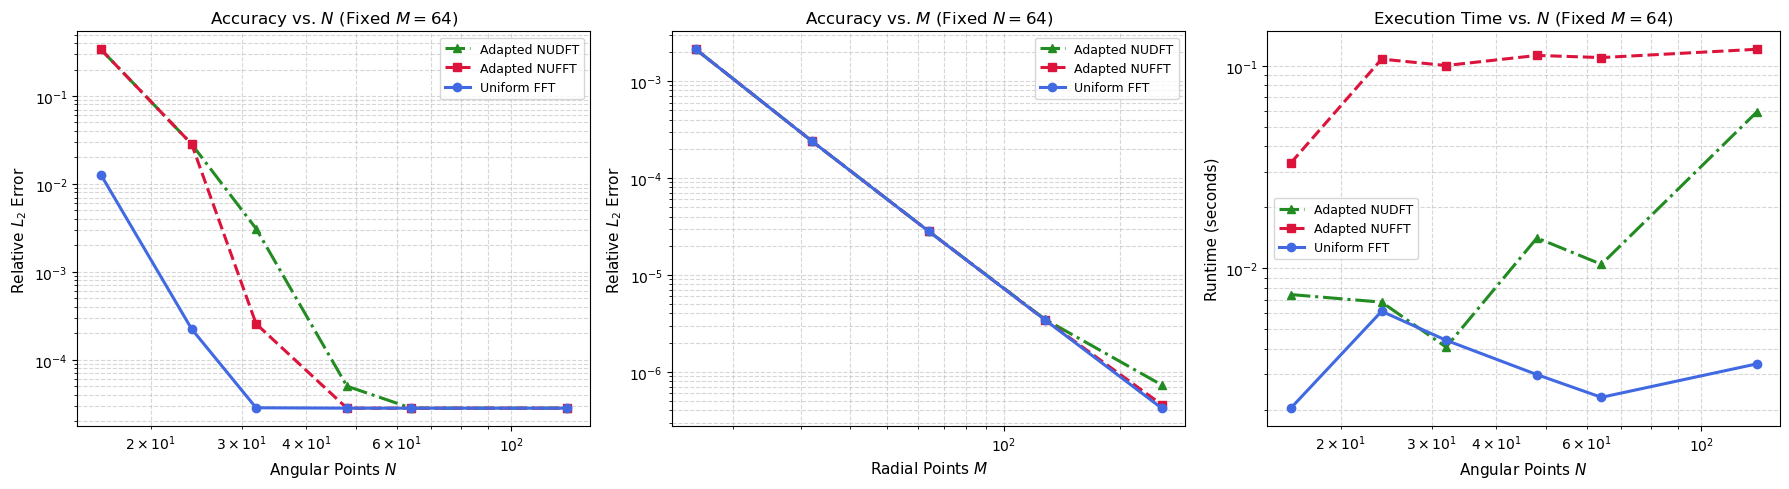

In [12]:
plot_accuracy_and_runtimes_from_df(
    df_results=df_results,
    fixed_M=M_FIXED_PLOTS,
    fixed_N=64
)

## 6. $3 \times 3$ Disk Error Comparison (Equal Resolution)
3D pointwise error surfaces on the disk at equal resolutions across:
- **Rows:** $N = 32, 64, 128$
- **Columns:** Adapted NUFFT | Adapted NUDFT | Uniform FFT

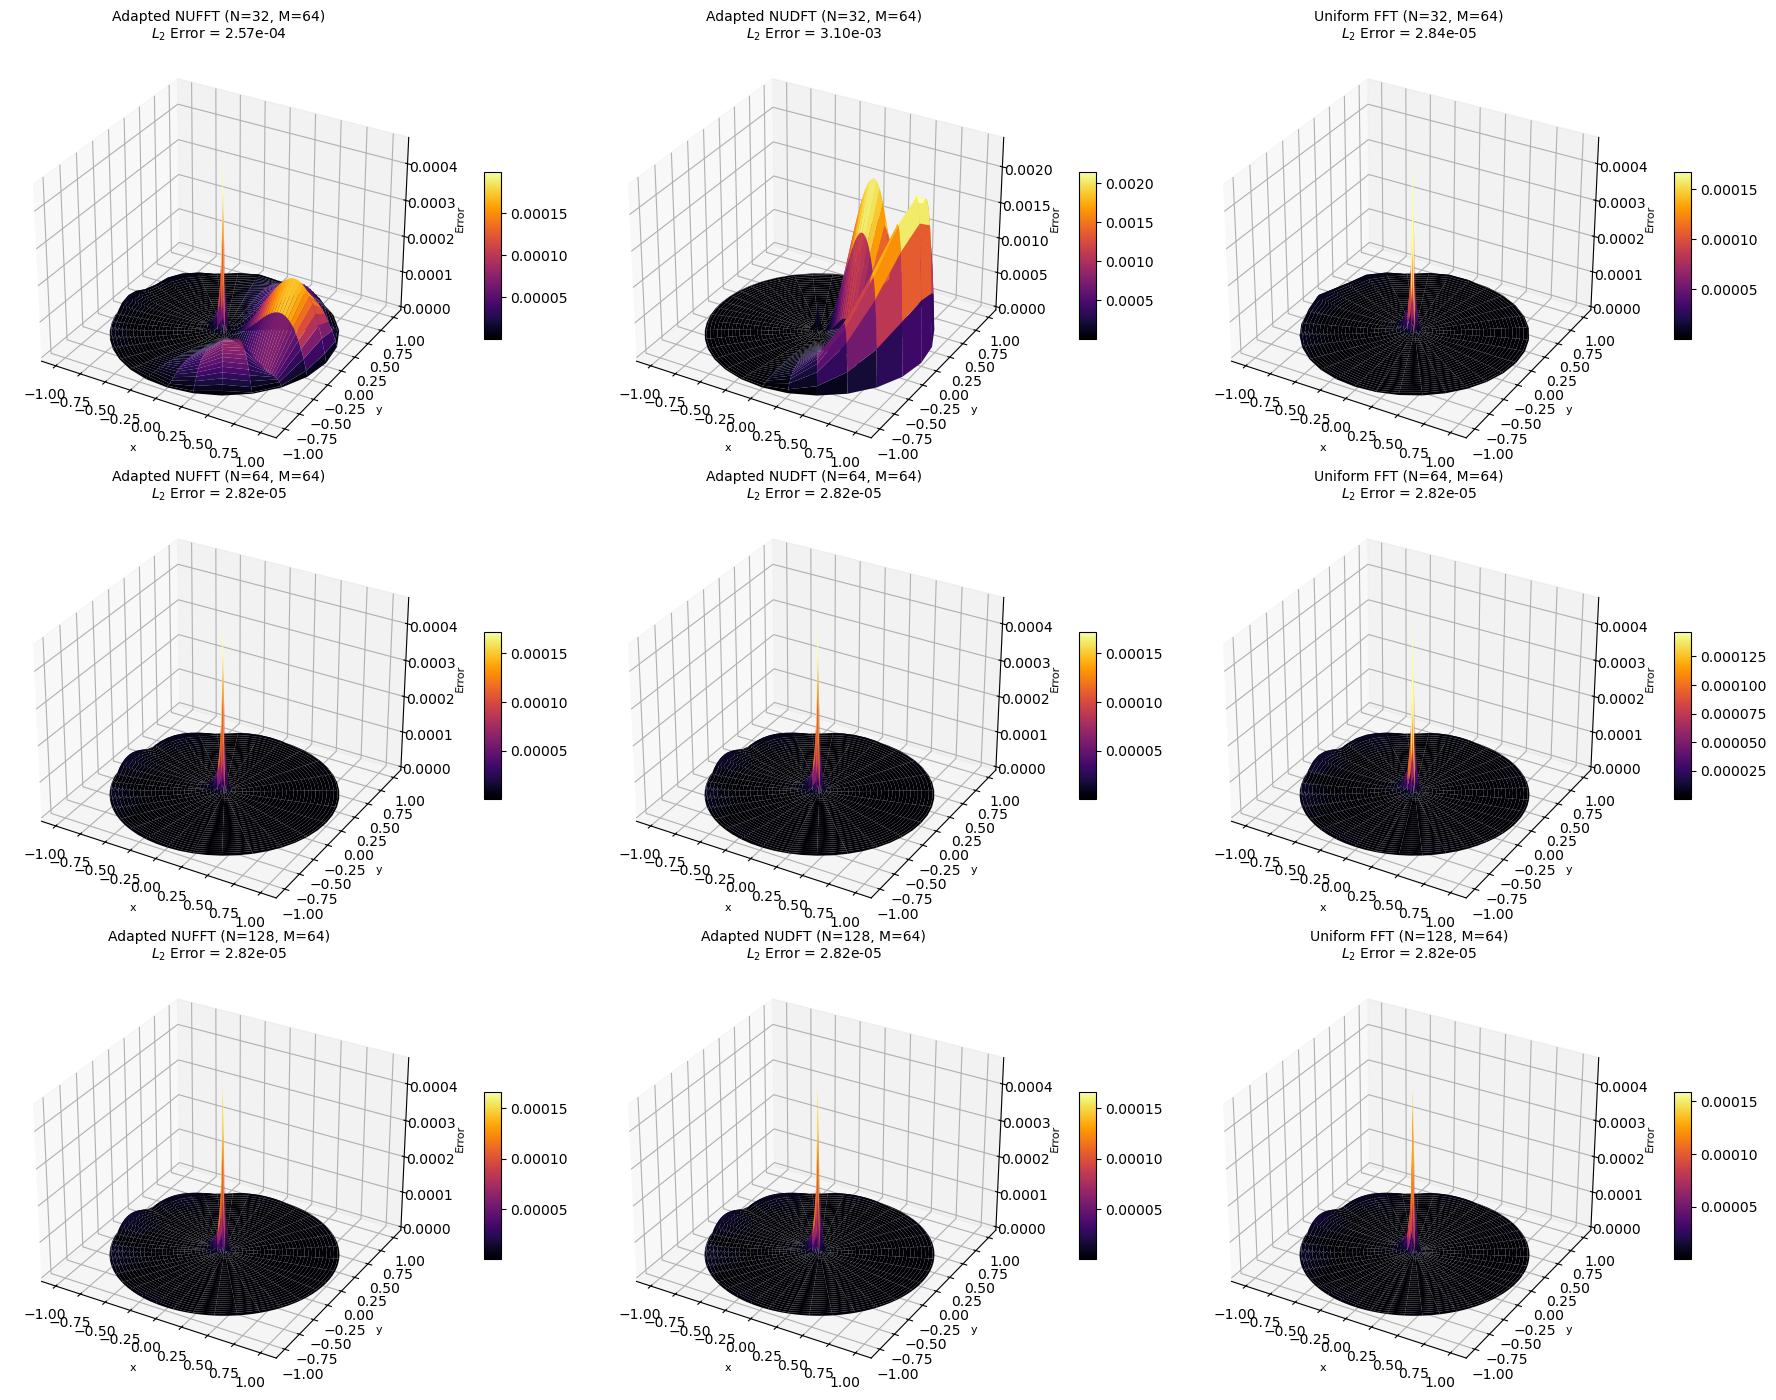

In [13]:
plot_3x3_disk_error_comparison(
    problem=problem,
    N_list=[32, 64, 128],
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)

## 7. Disk Error Comparison with Higher-Resolution Uniform Grid
Side-by-side 3D error surfaces comparing Adapted NUFFT ($N=32$) and Adapted NUDFT ($N=32$) against the higher-resolution Uniform FFT ($N=256$).

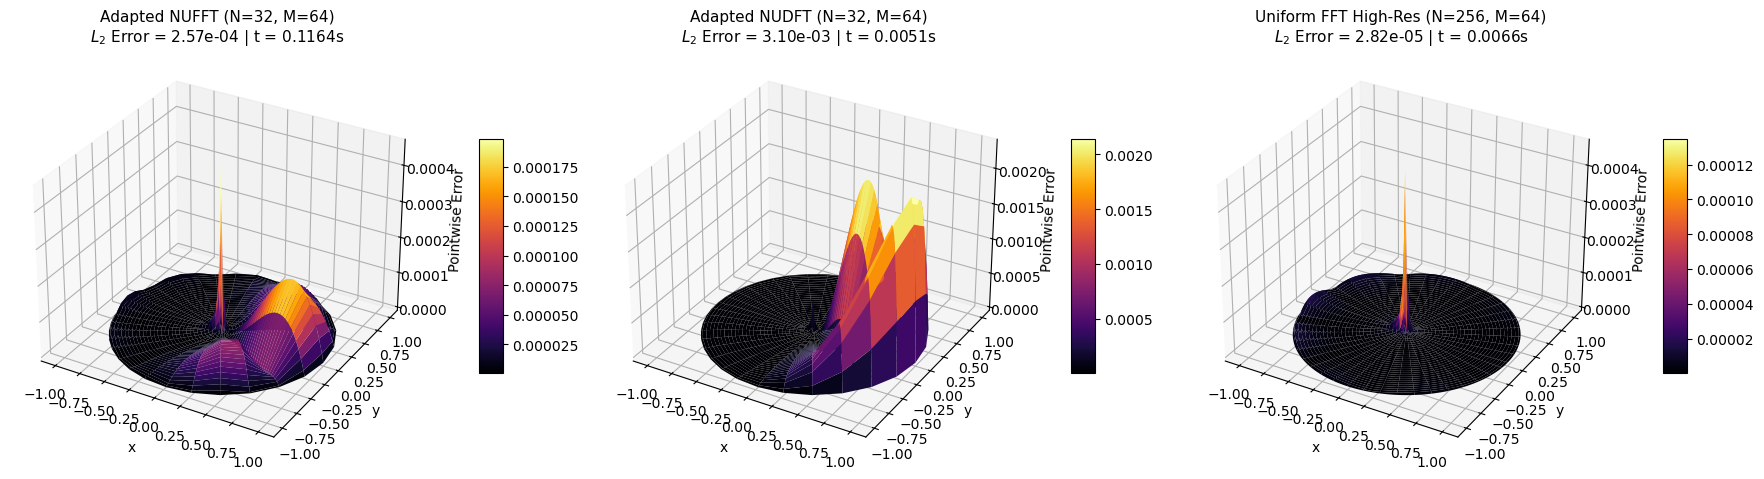

In [14]:
plot_adapted_vs_highres_uniform(
    problem=problem,
    N_adapt=N_LOW_ADAPT,
    N_unif_high=N_HIGH_UNIFORM,
    M=M_FIXED_PLOTS,
    cluster_strength=CLUSTER_STRENGTH,
    theta_0=THETA_0,
    quad_rule=QUAD_RULE,
    bc_choice=BC_CHOICE
)